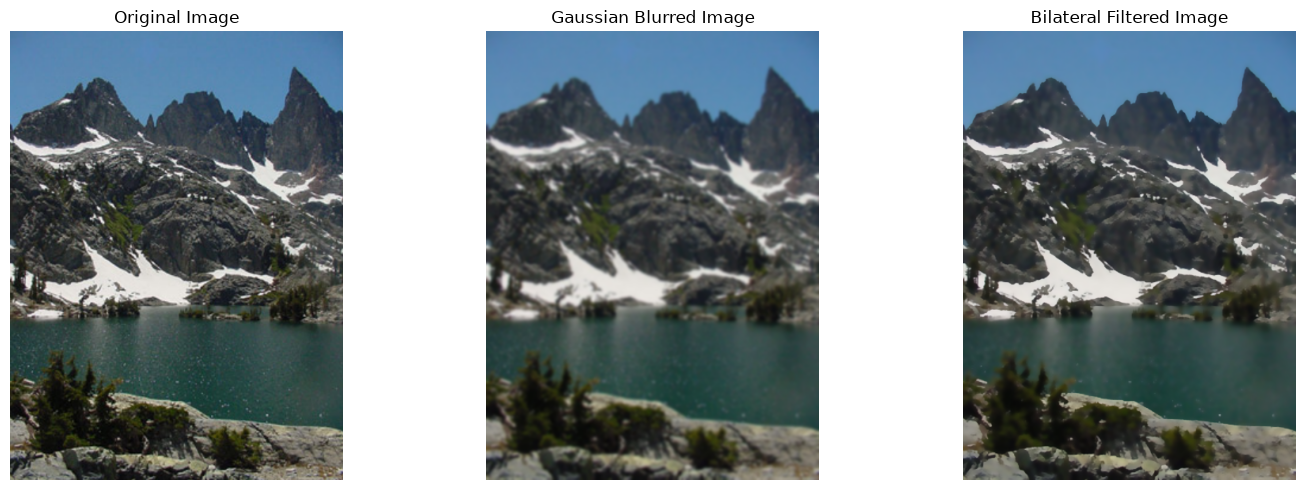

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt


image = cv.imread(
    r'D:\Image processing and Computer Vision\Images\mountains.png'
)

assert image is not None

image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

gaussian_blurred = cv.GaussianBlur(
    image,
    (9, 9),
    0
)

bilateral_filtered = cv.bilateralFilter(
    image,
    9,
    75,
    75
)

gaussian_rgb = cv.cvtColor(
    gaussian_blurred,
    cv.COLOR_BGR2RGB
)

bilateral_rgb = cv.cvtColor(
    bilateral_filtered,
    cv.COLOR_BGR2RGB
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilateral_rgb)
plt.title("Bilateral Filtered Image")
plt.axis("off")

plt.tight_layout()
plt.show()

MSE between OpenCV and custom bilateral filter: 18.310027216071028
PSNR between OpenCV and custom bilateral filter: 35.50391371029312 dB


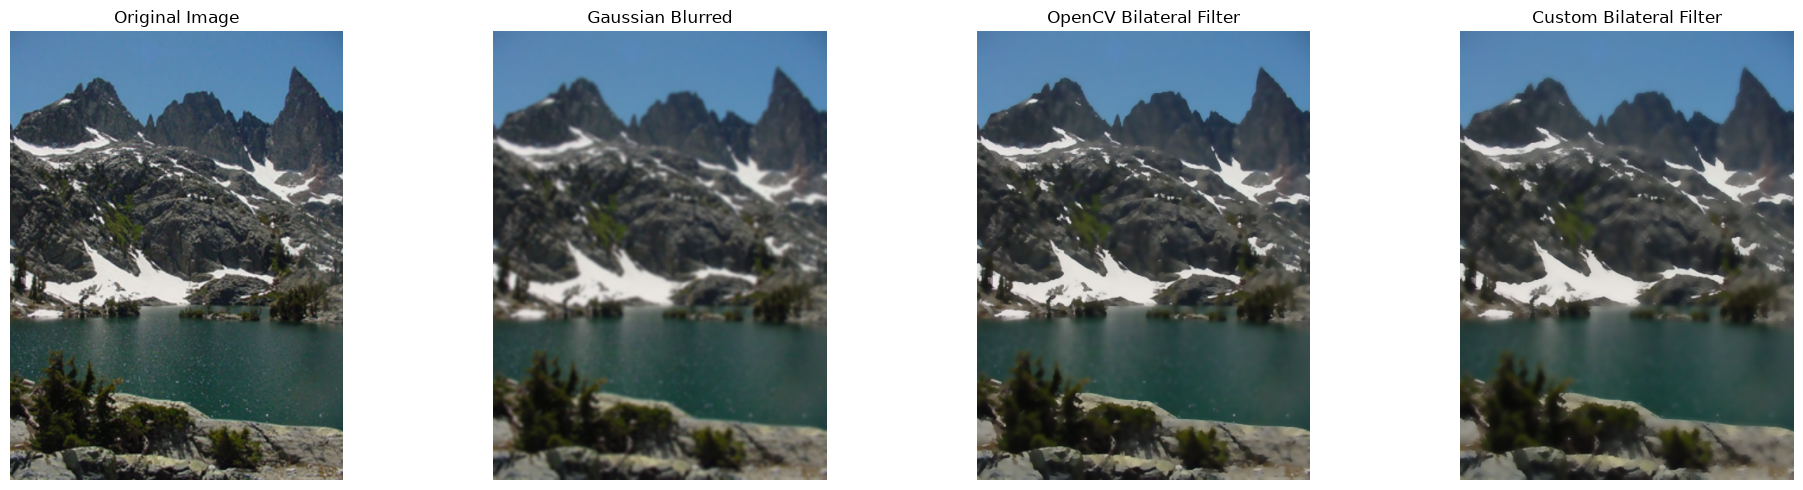

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def bilateral_filter(image, diameter, sigma_s, sigma_r):
    height, width, channels = image.shape

    radius = diameter // 2

    padded_image = cv.copyMakeBorder(
        image,
        radius,
        radius,
        radius,
        radius,
        cv.BORDER_REFLECT
    )

    output = np.zeros_like(image, dtype=np.float32)

    spatial_kernel = np.zeros(
        (diameter, diameter),
        dtype=np.float32
    )

    for i in range(diameter):
        for j in range(diameter):
            x = i - radius
            y = j - radius

            spatial_kernel[i, j] = np.exp(
                -(x ** 2 + y ** 2) /
                (2 * sigma_s ** 2)
            )

    for i in range(height):
        for j in range(width):
            center_pixel = padded_image[
                i + radius,
                j + radius
            ].astype(np.float32)

            weighted_sum = np.zeros(
                channels,
                dtype=np.float32
            )

            weight_total = 0.0

            for m in range(diameter):
                for n in range(diameter):
                    neighbor_pixel = padded_image[
                        i + m,
                        j + n
                    ].astype(np.float32)

                    intensity_difference = (
                        neighbor_pixel - center_pixel
                    )

                    range_weight = np.exp(
                        -np.sum(
                            intensity_difference ** 2
                        ) /
                        (2 * sigma_r ** 2)
                    )

                    weight = (
                        spatial_kernel[m, n] *
                        range_weight
                    )

                    weighted_sum += (
                        weight * neighbor_pixel
                    )

                    weight_total += weight

            output[i, j] = (
                weighted_sum / weight_total
            )

    return np.clip(output, 0, 255).astype(np.uint8)


def calculate_mse(image1, image2):
    image1 = image1.astype(np.float64)
    image2 = image2.astype(np.float64)

    return np.mean(
        (image1 - image2) ** 2
    )


def calculate_psnr(image1, image2):
    mse = calculate_mse(image1, image2)

    if mse == 0:
        return float("inf")

    return 10 * np.log10(
        (255 ** 2) / mse
    )


image = cv.imread(
    r'D:\Image processing and Computer Vision\Images\mountains.png'
)

assert image is not None

image_rgb = cv.cvtColor(
    image,
    cv.COLOR_BGR2RGB
)

diameter = 9
sigma_s = 75
sigma_r = 75

gaussian_blurred = cv.GaussianBlur(
    image,
    (diameter, diameter),
    0
)

opencv_bilateral = cv.bilateralFilter(
    image,
    diameter,
    sigma_r,
    sigma_s
)

custom_bilateral = bilateral_filter(
    image,
    diameter,
    sigma_s,
    sigma_r
)

gaussian_rgb = cv.cvtColor(
    gaussian_blurred,
    cv.COLOR_BGR2RGB
)

opencv_bilateral_rgb = cv.cvtColor(
    opencv_bilateral,
    cv.COLOR_BGR2RGB
)

custom_bilateral_rgb = cv.cvtColor(
    custom_bilateral,
    cv.COLOR_BGR2RGB
)

mse = calculate_mse(
    opencv_bilateral,
    custom_bilateral
)

psnr = calculate_psnr(
    opencv_bilateral,
    custom_bilateral
)

print("MSE between OpenCV and custom bilateral filter:", mse)
print("PSNR between OpenCV and custom bilateral filter:", psnr, "dB")

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(opencv_bilateral_rgb)
plt.title("OpenCV Bilateral Filter")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(custom_bilateral_rgb)
plt.title("Custom Bilateral Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
mse = calculate_mse(
    opencv_bilateral,
    custom_bilateral
)

psnr = calculate_psnr(
    opencv_bilateral,
    custom_bilateral
)

print("MSE:", mse)
print("PSNR:", psnr, "dB")

MSE: 18.310027216071028
PSNR: 35.50391371029312 dB


The Gaussian-filtered image appears smoother but causes noticeable blurring around edges. In contrast, both the OpenCV bilateral filter and the custom bilateral filter reduce noise while preserving important edges such as the boundaries of the mountains, trees, and lake. The custom implementation produces a result visually similar to the OpenCV implementation. The MSE measures the average pixel-wise difference between the two bilateral-filtered outputs, while the PSNR indicates their similarity. A low MSE and high PSNR demonstrate that the custom implementation approximates OpenCV’s bilateral filter effectively.